# 4.3. 3차원 상자 속 입자

In [1]:
import numpy as np
from collections import defaultdict

groups = defaultdict(list)
for nx in range(1, 7):
    for ny in range(1, 7):
        for nz in range(1, 7):
            groups[nx**2 + ny**2 + nz**2].append((nx, ny, nz))

for key in sorted(groups)[:8]:
    states = groups[key]
    print(f"E = {key:2d} E0 : {states} - {len(states)}중 축퇴")

E =  3 E0 : [(1, 1, 1)] - 1중 축퇴
E =  6 E0 : [(1, 1, 2), (1, 2, 1), (2, 1, 1)] - 3중 축퇴
E =  9 E0 : [(1, 2, 2), (2, 1, 2), (2, 2, 1)] - 3중 축퇴
E = 11 E0 : [(1, 1, 3), (1, 3, 1), (3, 1, 1)] - 3중 축퇴
E = 12 E0 : [(2, 2, 2)] - 1중 축퇴
E = 14 E0 : [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)] - 6중 축퇴
E = 17 E0 : [(2, 2, 3), (2, 3, 2), (3, 2, 2)] - 3중 축퇴
E = 18 E0 : [(1, 1, 4), (1, 4, 1), (4, 1, 1)] - 3중 축퇴


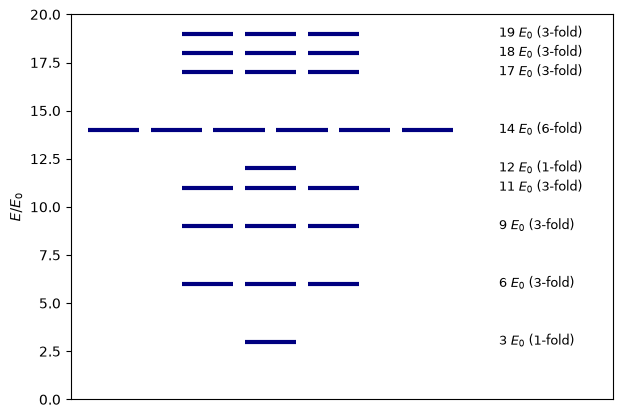

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for key in sorted(groups)[:9]:
    g = len(groups[key])
    for j in range(g):
        x0 = 0.5 + (j - (g - 1) / 2) * 0.22
        ax.hlines(key, x0 - 0.09, x0 + 0.09, lw=3, color="navy")
    ax.text(1.3, key, f"{key} $E_0$ ({g}-fold)", va="center", fontsize=9)

ax.set_xlim(-0.2, 1.7)
ax.set_ylim(0, 20)
ax.set_xticks([])
ax.set_ylabel("$E / E_0$")
plt.show()

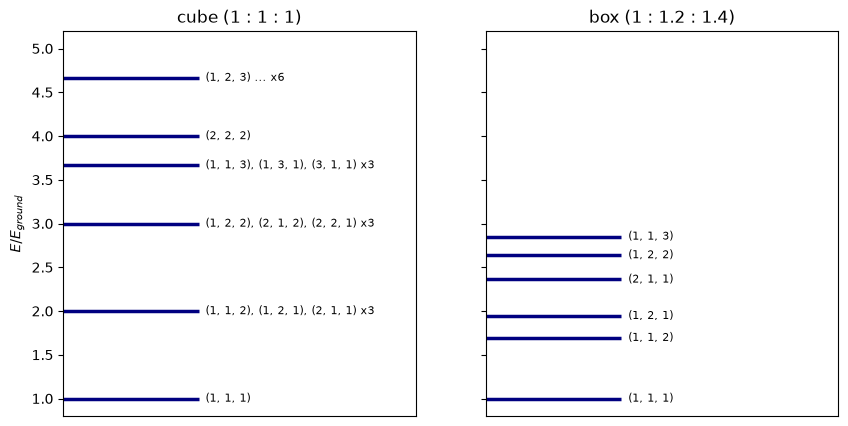

In [3]:
def levels(a, b, c):
    g = defaultdict(list)
    for nx in range(1, 4):
        for ny in range(1, 4):
            for nz in range(1, 4):
                g[round((nx / a) ** 2 + (ny / b) ** 2 + (nz / c) ** 2, 5)].append(
                    (nx, ny, nz)
                )
    return g


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (a, b, c, title) in zip(
    axes, [(1, 1, 1, "cube (1 : 1 : 1)"), (1, 1.2, 1.4, "box (1 : 1.2 : 1.4)")]
):
    g = levels(a, b, c)
    ground = min(g)
    for val in sorted(g)[:6]:
        states = sorted(g[val])
        ax.hlines(val / ground, 0, 1, lw=2.5, color="navy")
        lab = ", ".join(str(s) for s in states[:3])
        if len(states) > 3:
            lab = f"{states[0]} ... x{len(states)}"
        elif len(states) > 1:
            lab += f" x{len(states)}"
        ax.text(1.05, val / ground, lab, va="center", fontsize=8)
    ax.set_xlim(0, 2.6)
    ax.set_xticks([])
    ax.set_title(title)

axes[0].set_ylabel("$E / E_{ground}$")
axes[0].set_ylim(0.8, 5.2)
plt.show()

In [4]:
for key in sorted(groups):
    shapes = {tuple(sorted(s)) for s in groups[key]}
    if len(shapes) > 1:
        print(f"E = {key} E0 : {sorted(shapes)}")

E = 27 E0 : [(1, 1, 5), (3, 3, 3)]
E = 33 E0 : [(1, 4, 4), (2, 2, 5)]
E = 38 E0 : [(1, 1, 6), (2, 3, 5)]
E = 41 E0 : [(1, 2, 6), (3, 4, 4)]
E = 54 E0 : [(2, 5, 5), (3, 3, 6)]


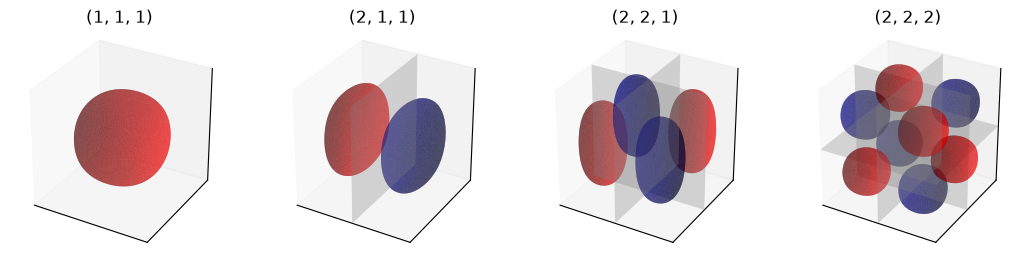

In [5]:
from skimage import measure

# scikit-image 패키지는 Colab에는 이미 설치되어 있지만, 로컬 환경에서 실행시키려면 추가로 설치해야 합니다.

L, N = 1.0, 60
g = np.linspace(0, L, N)
X, Y, Z = np.meshgrid(g, g, g, indexing="ij")


def psi3(nx, ny, nz):
    return (
        np.sin(nx * np.pi * X / L)
        * np.sin(ny * np.pi * Y / L)
        * np.sin(nz * np.pi * Z / L)
    )


def draw(ax, nx, ny, nz, iso=0.45):
    psi = psi3(nx, ny, nz)

    for level, color in [(iso, "red"), (-iso, "navy")]:
        if not psi.min() < level < psi.max():
            continue
        verts, faces, _, _ = measure.marching_cubes(
            psi, level, spacing=(L / (N - 1),) * 3
        )
        ax.plot_trisurf(
            verts[:, 0], verts[:, 1], faces, verts[:, 2], color=color, alpha=0.5, lw=0
        )

    for axis, n in enumerate([nx, ny, nz]):
        for j in range(1, n):
            pos = L * j / n
            u, v = np.meshgrid([0, L], [0, L])
            flat = np.full_like(u, pos, dtype=float)
            planes = [(flat, u, v), (u, flat, v), (u, v, flat)]

            ax.plot_surface(*planes[axis], color="gray", alpha=0.3, shade=False)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_title(f"({nx}, {ny}, {nz})", fontsize=12)


fig = plt.figure(figsize=(13, 4))
for i, state in enumerate([(1, 1, 1), (2, 1, 1), (2, 2, 1), (2, 2, 2)], 1):
    ax = fig.add_subplot(1, 4, i, projection="3d")
    draw(ax, *state)

plt.show()